In [7]:
import sys, os
sys.path.append(os.path.abspath(".."))  # go up one level so 'blocks' is visible

import dowhy
from dowhy import CausalModel
import dowhy.datasets
import numpy as np
import pandas as pd
from blocks.draw import draw_duplo_dag, duplo_to_dot, duplo_to_networkx
from blocks.add_node import add_node
from blocks.utils import get_variable_color, COLORS, SEABORN_PALETTE, set_seaborn_theme
from blocks.dowhy import dowhy_help
from blocks.simulate import simulate_data

import warnings
warnings.filterwarnings('ignore')

# Set seaborn styling
set_seaborn_theme()

plt.rcParams['figure.figsize'] = (12, 8)  # Bigger default size
plt.rcParams['figure.dpi'] = 100          # Screen display
plt.rcParams['savefig.dpi'] = 300  

In [2]:
# Load your data
df = pd.read_csv('../data/english_education.csv')  # Update with your actual filename

# Filter and clean
size_order = ['Small Towns', 'Medium Towns', 'Large Towns']
df_filtered = df[df['size_flag'].isin(size_order)].copy()
df_filtered = df_filtered[['coastal', 'rgn11nm', 'size_flag', 
                            'income_flag', 'education_score']].dropna()

# Encode size as ordinal (0=Small, 1=Medium, 2=Large)
df_filtered['size_numeric'] = df_filtered['size_flag'].map({
    'Small Towns': 0,
    'Medium Towns': 1,
    'Large Towns': 2
})

DAG saved to figures/uk_education_dag.png


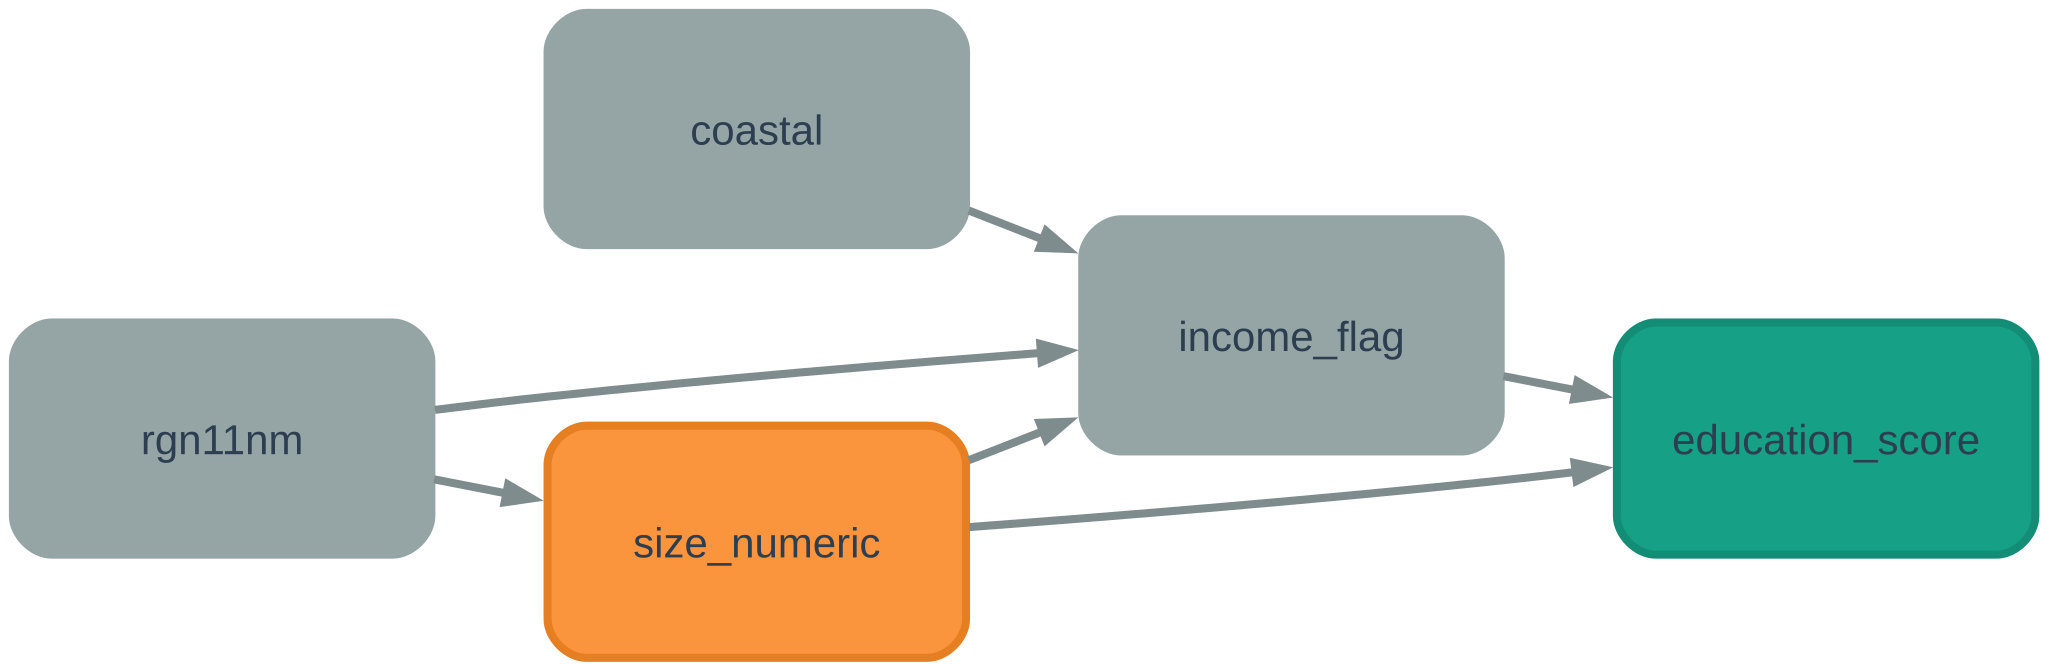

In [3]:
# Build the DAG
education_dag = []

add_node(education_dag, "coastal", get_variable_color('confounder'), 
         targets=["income_flag"])
add_node(education_dag, "rgn11nm", get_variable_color('confounder'), 
         targets=["income_flag", "size_numeric"])
add_node(education_dag, "size_numeric", get_variable_color('treatment'), 
         targets=["income_flag", "education_score"])
add_node(education_dag, "income_flag", get_variable_color('confounder'), 
         targets=["education_score"])
add_node(education_dag, "education_score", get_variable_color('outcome'), 
         targets=[])

draw_duplo_dag(education_dag, save_path='figures/uk_education_dag.png')

In [13]:
# Create DoWhy model
model = CausalModel(
    data=df_filtered,
    treatment='size_numeric',
    outcome='education_score',
    graph=duplo_to_dot(education_dag)
)

In [14]:
# Step 1: Identify the estimand (what to calculate)
estimand = model.identify_effect()
print(estimand)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
       d                                   
───────────────(E[education_score|rgn11nm])
d[size_numeric]                            
Estimand assumption 1, Unconfoundedness: If U→{size_numeric} and U→education_score then P(education_score|size_numeric,rgn11nm,U) = P(education_score|size_numeric,rgn11nm)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
       d                                   
───────────────(E[education_score|rgn11nm])
d[size_numeric]                            
Estimand assumption 1, Unconfoundedness: If U→{size_numeric} and U→education_score then P(education_score|size_numeric,rgn11nm,U) = P(education_score|size_numeric,rgn11nm)



In [15]:
# Step 2: Estimate the causal effect
# Using backdoor adjustment (regression)
estimate = model.estimate_effect(
    estimand,
    method_name="backdoor.linear_regression"
)
print("\n=== CAUSAL EFFECT ESTIMATE ===")
print(estimate)


=== CAUSAL EFFECT ESTIMATE ===
*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
       d                                   
───────────────(E[education_score|rgn11nm])
d[size_numeric]                            
Estimand assumption 1, Unconfoundedness: If U→{size_numeric} and U→education_score then P(education_score|size_numeric,rgn11nm,U) = P(education_score|size_numeric,rgn11nm)

## Realized estimand
b: education_score~size_numeric+rgn11nm+size_numeric*coastal
Target units: 

## Estimate
Mean value: -0.6657839765998235
### Conditional Estimates
coastal
Coastal       -1.613797
Non-coastal   -0.517910
dtype: float64


In [16]:
# Step 3: Check if result is robust (refutation tests)
print("\n=== SENSITIVITY TESTS ===")

# Test 1: Add random confounder (should show no effect if model is good)
refute1 = model.refute_estimate(estimand, estimate, 
                                 method_name="random_common_cause")
print(refute1)

# Test 2: Placebo treatment (replace treatment with random variable)
refute2 = model.refute_estimate(estimand, estimate,
                                 method_name="placebo_treatment_refuter")
print(refute2)

# Test 3: Data subset validation
refute3 = model.refute_estimate(estimand, estimate,
                                 method_name="data_subset_refuter")
print(refute3)


=== SENSITIVITY TESTS ===
Refute: Add a random common cause
Estimated effect:-0.6657839765998235
New effect:-0.6662955437053997
p value:1.0

Refute: Use a Placebo Treatment
Estimated effect:-0.6657839765998235
New effect:-0.013553675058699872
p value:0.82

Refute: Use a subset of data
Estimated effect:-0.6657839765998235
New effect:-0.6571117858606083
p value:0.8400000000000001



In [17]:
# Add this to see the total effect
print("\n=== COMPARISON ===")
print("Naive correlation (no controls):")
naive_effect = df_filtered.groupby('size_numeric')['education_score'].mean()
print(naive_effect)
print(f"\nSlope without controls: {(naive_effect[2] - naive_effect[0]) / 2:.2f} per category")
print(f"Causal effect (with controls): {estimate.value:.2f} per category")
print(f"\nIncome/region explains: {abs((naive_effect[2] - naive_effect[0]) / 2 - estimate.value):.2f} points")


=== COMPARISON ===
Naive correlation (no controls):
size_numeric
0    0.296617
1   -0.253095
2   -0.811495
Name: education_score, dtype: float64

Slope without controls: -0.55 per category
Causal effect (with controls): -0.67 per category

Income/region explains: 0.11 points


In [18]:
import statsmodels.formula.api as smf

# WITHOUT controlling for income (total effect)
model_total = smf.ols('education_score ~ size_numeric + C(rgn11nm) + C(coastal)', 
                      data=df_filtered).fit()
total_effect = model_total.params['size_numeric']

# WITH controlling for income (direct effect only)
model_direct = smf.ols('education_score ~ size_numeric + C(income_flag) + C(rgn11nm) + C(coastal)', 
                       data=df_filtered).fit()
direct_effect = model_direct.params['size_numeric']

print(f"Total effect (no income control): {total_effect:.2f}")
print(f"Direct effect (controlling for income): {direct_effect:.2f}")
print(f"Indirect effect (through income): {total_effect - direct_effect:.2f}")

Total effect (no income control): -0.62
Direct effect (controlling for income): 0.34
Indirect effect (through income): -0.96


In [19]:
# What are the income categories?
print("Income categories:")
print(df_filtered['income_flag'].value_counts())

# What's the education score for each income level?
print("\nAverage education score by income level:")
income_edu = df_filtered.groupby('income_flag')['education_score'].agg(['mean', 'count', 'std'])
print(income_edu.sort_values('mean'))

# Calculate the actual income effect
low_dep = df_filtered[df_filtered['income_flag'] == 'Lower deprivation towns']['education_score'].mean()
high_dep = df_filtered[df_filtered['income_flag'] == 'Higher deprivation towns']['education_score'].mean()

print(f"\nActual income effect:")
print(f"Lower deprivation (wealthy): {low_dep:.2f}")
print(f"Higher deprivation (poor): {high_dep:.2f}")
print(f"Difference: {low_dep - high_dep:.2f} points")

Income categories:
income_flag
Lower deprivation towns     444
Higher deprivation towns    433
Mid deprivation towns       205
Name: count, dtype: int64

Average education score by income level:
                              mean  count       std
income_flag                                        
Higher deprivation towns -2.421538    433  2.455993
Mid deprivation towns    -0.663287    205  2.595515
Lower deprivation towns   2.758699    444  3.096247

Actual income effect:
Lower deprivation (wealthy): 2.76
Higher deprivation (poor): -2.42
Difference: 5.18 points


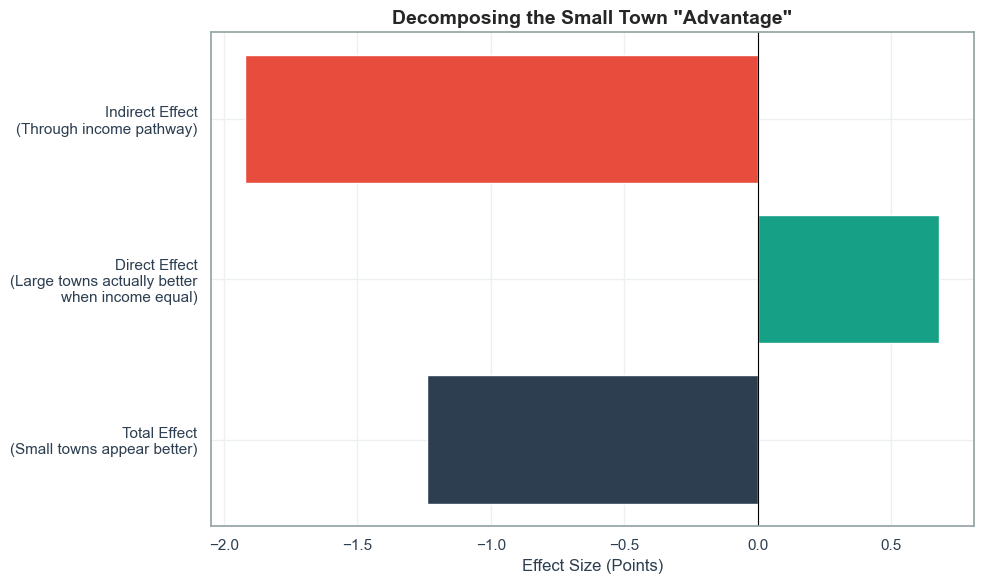

In [9]:
import matplotlib.pyplot as plt

effects = {
    'Total Effect\n(Small towns appear better)': -1.24,
    'Direct Effect\n(Large towns actually better\nwhen income equal)': 0.68,
    'Indirect Effect\n(Through income pathway)': -1.92
}

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(list(effects.keys()), list(effects.values()), 
               color=['#2c3e50', '#16a085', '#e74c3c'])

ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax.set_xlabel('Effect Size (Points)', fontsize=12)
ax.set_title('Decomposing the Small Town "Advantage"', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('effect_size_income.png', bbox_inches='tight', facecolor='white')
plt.show()

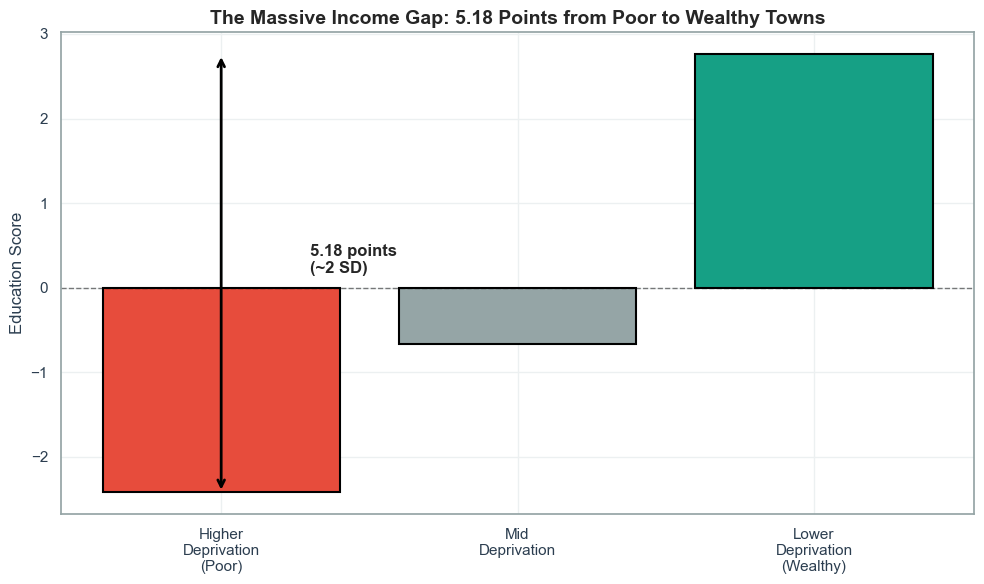

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))

income_levels = ['Higher\nDeprivation\n(Poor)', 'Mid\nDeprivation', 'Lower\nDeprivation\n(Wealthy)']
scores = [-2.42, -0.66, 2.76]
colors_income = ['#e74c3c', '#95a5a6', '#16a085']

bars = ax.bar(income_levels, scores, color=colors_income, edgecolor='black', linewidth=1.5)

ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.set_ylabel('Education Score', fontsize=12)
ax.set_title('The Massive Income Gap: 5.18 Points from Poor to Wealthy Towns', 
             fontsize=14, fontweight='bold')

# Annotate the gap
ax.annotate('', xy=(0, 2.76), xytext=(0, -2.42),
            arrowprops=dict(arrowstyle='<->', lw=2, color='black'))
ax.text(0.3, 0.17, '5.18 points\n(~2 SD)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

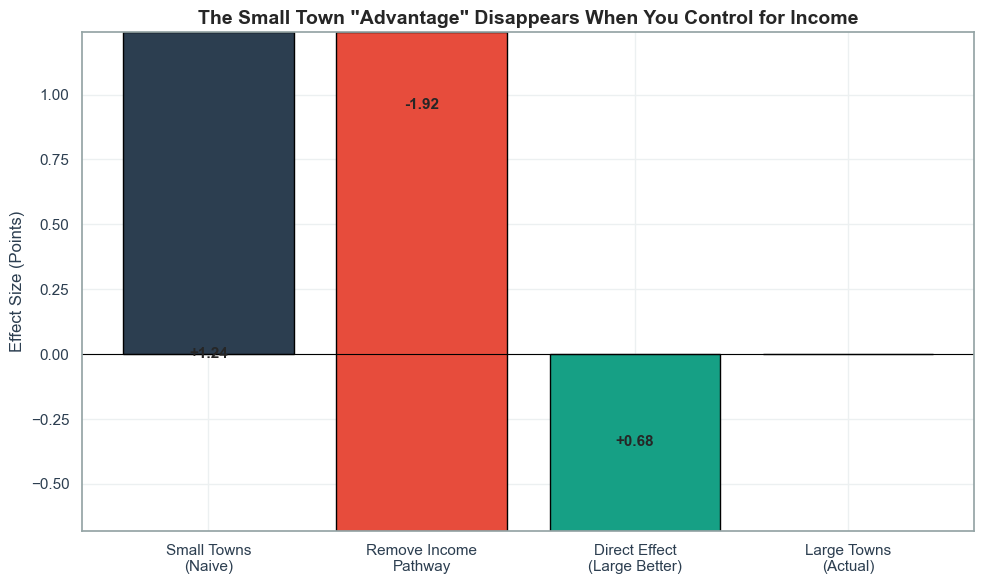

In [6]:
import matplotlib.pyplot as plt
import numpy as np

categories = ['Small Towns\n(Naive)', 'Remove Income\nPathway', 'Direct Effect\n(Large Better)', 'Large Towns\n(Actual)']
values = [1.24, -1.92, 0.68, 0]  # Cumulative

fig, ax = plt.subplots(figsize=(10, 6))

# Starting bar
ax.bar(0, values[0], color='#2c3e50', edgecolor='black')

# Waterfall bars
cumsum = values[0]
for i in range(1, len(values)-1):
    ax.bar(i, values[i], bottom=cumsum if values[i] < 0 else cumsum, 
           color='#e74c3c' if values[i] < 0 else '#16a085', 
           edgecolor='black')
    cumsum += values[i]

# Final bar
ax.bar(3, cumsum, color='#fa953d', edgecolor='black')

# Add labels
for i, v in enumerate(values):
    if i < len(values)-1:
        y_pos = cumsum if i == 0 else cumsum - v/2
        ax.text(i, y_pos, f'{v:+.2f}', ha='center', va='center', 
                fontweight='bold', fontsize=11)

ax.set_xticks(range(len(categories)))
ax.set_xticklabels(categories)
ax.set_ylabel('Effect Size (Points)', fontsize=12)
ax.set_title('The Small Town "Advantage" Disappears When You Control for Income', 
             fontsize=14, fontweight='bold')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)

plt.tight_layout()
plt.show()